---
title: A Study On Logistic Regression
date: "2025-08-03"
toc: true
tags: [math, machine learning]
sitemap:
    changefreq: never
    priority: 1.0
categories: [study]
description: This article introduces and explore a classic machine learning algorithm, Logistic Regression.
---

In [16]:
#|echo: false

import numpy as np
import matplotlib.pyplot as plt

# Logistic Regression

implementation of a logistic regression

In [17]:
class LogisticRegression:

    def __init__(self, lr=0.01, epochs=1000, threshold=0.5):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.threshold = threshold
        self.losses = []
        self.history = []

    def _linear(self, X):
        return X @ self.w + self.b

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z + 1e-5))

    def predict_prob(self, X):
        return self._sigmoid(self._linear(X))

    def predict(self, X):
        return (self.predict_prob(X) >= self.threshold).astype(int)

    def loss(self, X, y):
        y_prob = self.predict_prob(X)
        eps = 1e-15
        y_prob = np.clip(y_prob, eps, 1 - eps)
        return -(1 / X.shape[0]) * (np.sum(y * np.log(y_prob)) + np.sum(
            (1 - y) * np.log(1 - y_prob)))

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])

        for i in range(self.epochs):
            loss = self.loss(X, y)
            self.losses.append(loss)
            y_prob = self.predict_prob(X)

            # Gradient Descent
            dw = (1 / X.shape[0]) * X.T @ (y_prob - y)
            db = (1 / X.shape[0]) * np.sum(y_prob - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            # calculate how much did the hyperplane has "rotate" by a inner product of their normal vectors
            cos_theta = 0
            if self.history:
                cos_theta = np.dot(self.w, self.history[-1][0]) / (
                    np.linalg.norm(self.w) * np.linalg.norm(self.history[-1][0]))
                cos_theta = np.clip(cos_theta, -1.0, 1.0)

            angle_deg = np.degrees(np.arccos(cos_theta))

            # record history only when there is a big update
            if not self.history or angle_deg > 30 or i == self.epochs - 1:
                self.history.append([self.w.copy(), self.b, i])

#### Try Logistic Regression on a Synthetic Dataset

generate data


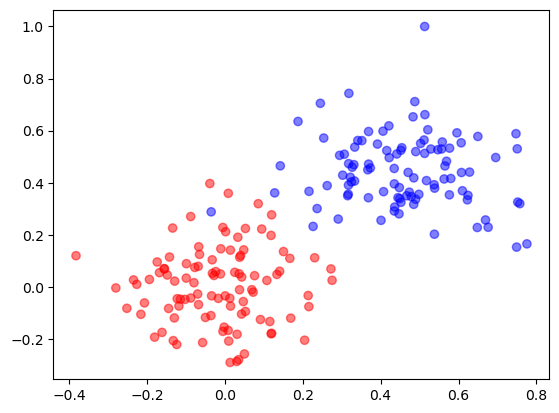

In [18]:
np.random.seed(42)

d1 = np.random.randn(100, 2)
d2 = np.random.randn(100, 2) + 3

X_dummy = np.vstack((d1, d2))
y_dummy = np.array([1] * 100 + [-1] * 100)

idx = np.random.permutation(len(X_dummy))
X_dummy = X_dummy[idx]
y_dummy = y_dummy[idx]

X_dummy = X_dummy / np.max(X_dummy)

plt.scatter(X_dummy[:, 0], X_dummy[:, 1], c=y_dummy, cmap="bwr", alpha=0.5)
plt.show()

learn


In [19]:
logistic = LogisticRegression(0.1, 200, 0.5)
logistic.fit(X_dummy, y_dummy)

loss


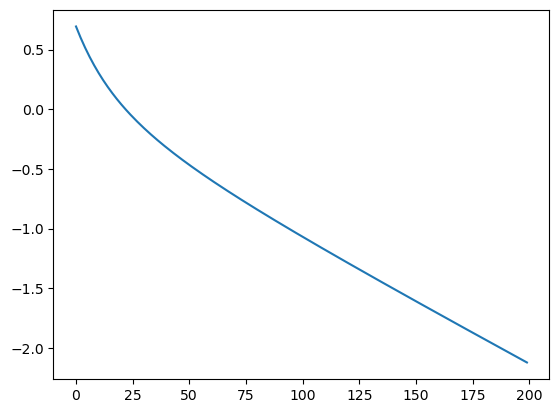

In [20]:
plt.plot(np.arange(len(logistic.losses)), logistic.losses)
plt.show()

visualize learning process


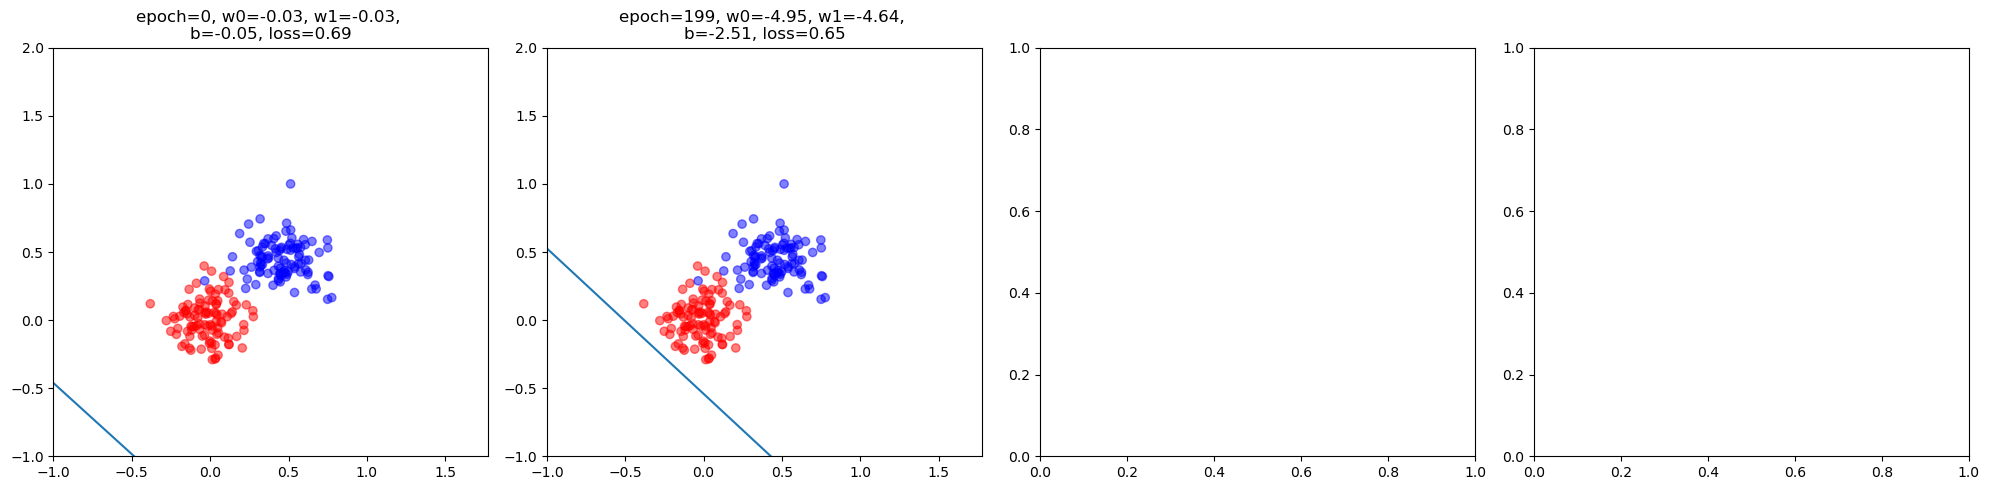

In [21]:
fig, axes = plt.subplots(nrows=int(np.ceil(len(logistic.history) / 4)),
                         ncols=4,
                         figsize=(20, 5))
axes = axes.flatten()
# print(p.losses)

x0_vals = np.linspace(X_dummy[:, 1].min() - 1, X_dummy[:, 1].max() + 1, 100)

for i, (cw, cb, epoch) in enumerate(logistic.history):

    axes[i].plot(
        x0_vals,
        -(cw[0] * x0_vals + cb) / cw[1],
    )

    axes[i].scatter(X_dummy[:, 0], X_dummy[:, 1], c=y_dummy, cmap='bwr', alpha=0.5)
    axes[i].set_xlim(-1, X_dummy[:, 0].max() + 1)
    axes[i].set_ylim(-1, X_dummy[:, 1].max() + 1)
    axes[i].set_title(
        f"epoch={epoch}, w0={cw[0]:.2f}, w1={cw[1]:.2f}, \nb={cb:.2f}, loss={logistic.losses[i]:.2f}"
    )
plt.tight_layout()
plt.show()

#### Try Logistic Regression on a Real Dataset

load data and learn


In [22]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label", "message"])


def clean_text(text):
    text = text.lower()
    text = re.sub(r"\W+", " ", text)
    return text.strip()


df["message"] = df["message"].apply(clean_text)

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["message"])
y = np.where(df["label"] == "spam", 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

classifier = LogisticRegression(lr=0.1, epochs=20000)

classifier.fit(X_train, y_train)

evaluate performance


In [23]:
y_pred = classifier.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

Accuracy: 0.9488789237668162
Precision: 1.0
Recall: 0.6174496644295302
F1 Score: 0.7634854771784232

Classification Report:

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       966
        spam       1.00      0.62      0.76       149

    accuracy                           0.95      1115
   macro avg       0.97      0.81      0.87      1115
weighted avg       0.95      0.95      0.94      1115



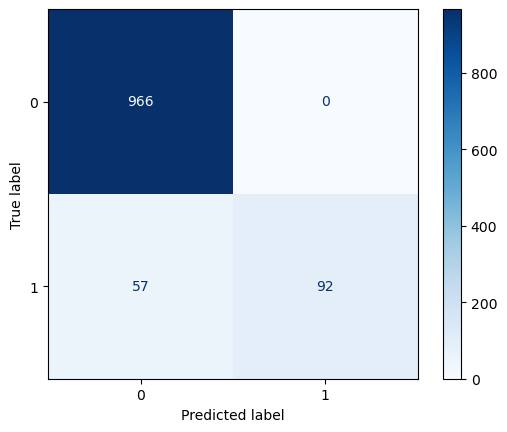

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize=None,
    cmap="Blues",
)
plt.show()

loss


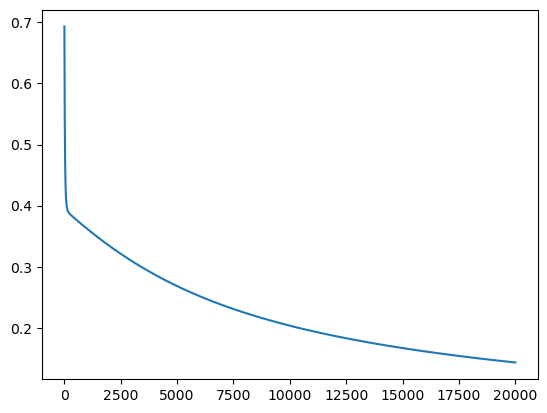

In [25]:
plt.plot(np.arange(len(classifier.losses)), classifier.losses)
plt.show()